## 5.2 합성곱 신경망 맛보기
- fashion mnist 데이터셋

In [4]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.autograd import Variable
import torch.nn.functional as F

import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

In [5]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

In [6]:
train_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data',
                                                  download=True,
                                                  transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = torchvision.datasets.FashionMNIST('/content/drive/MyDrive/data/딥러닝 파이토치 교과서/chap05/data',
                                                 download=True,
                                                 train = False,
                                                 transform=transforms.Compose([transforms.ToTensor()]))

100%|██████████| 26.4M/26.4M [00:01<00:00, 17.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 282kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.10MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 2.78MB/s]


[torchvision.datasets]
- torch.utils.data.Dataset의 하위 클래스, 다양한 데이터셋 포함

[주요 파라미터]
1. 내려받을 위치 지정
2. download: True로 설정하면 위치에 해당 데이터셋에 있는지 확인한 후 내려 받음
3. transform: 이미지를 텐서로 변경

In [7]:
train_loader = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=100)
test_loader = torch.utils.data.DataLoader(test_dataset,
                                          batch_size = 100)

- torch.utils.data.DataLoader(): 원하는 크기의 배치 단위로 데이터를 불러오거나 순서가 무작위로 섞이도록 함

[주요 파라미터]
- 데이터를 불러올 데이터셋 지정
- batch_size: 데이터를 배치로 묶어줌

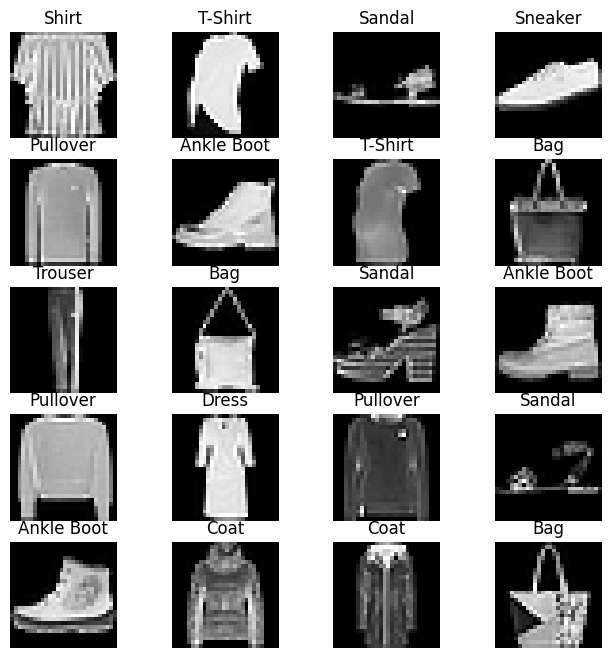

In [8]:
# 분류에 사용될 클래스 정의
labels_map={0:'T-Shirt', 1:'Trouser', 2:'Pullover', 3:'Dress', 4:'Coat',
            5:'Sandal', 6:'Shirt', 7:'Sneaker', 8:'Bag', 9:'Ankle Boot'}

fig=plt.figure(figsize=(8,8))
columns=4
rows=5
for i in range(1, columns*rows+1):
    img_xy=np.random.randint(len(train_dataset))
    img=train_dataset[img_xy][0][0,:,:]
    fig.add_subplot(rows, columns, i)
    plt.title(labels_map[train_dataset[img_xy][1]])
    plt.axis('off')
    plt.imshow(img, cmap='gray')
plt.show()

In [9]:
# 심층 신경망 코드 생성
class FashionDNN(nn.Module):
  def __init__(self):
    super(FashionDNN, self).__init__()
    self.fc1 = nn.Linear(in_features=784, out_features=256)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=256, out_features=128)
    self.fc3 = nn.Linear(in_features=128, out_features=10)

  def forward(self, input_data):
    out = input_data.view(-1, 784)
    out = F.relu(self.fc1(out))
    out = self.drop(out)
    out = F.relu(self.fc2(out))
    out = self.fc3(out)
    return out

- 클래스 형태의 모델은 항상 torch.nn.Module을 상속받음. `__init()__`은 객체가 갖는 속성 값을 초기화하는 역할을 하며, 객체가 생성될 때 자동으로 호출됨.
- nn은 딥러닝 모델 구성에 필요한 모듈이 모여 있는 패키지. Linear는 단순 선형 회귀 모델을 만들 때 사용함.
  - in_features: 입력의 크기
  - out_features: 출력의 크기
- torch.nn.Dropout(p)는 p만큼의 비율로 텐서의 값이 0이 되고, 0이 되지 않는 값들은 기존 값에 (1/(1-p))만큼 곱해져 커짐.
- forward() 함수는 모델이 학습 데이터를 입력받아서 순전파 학습을 진행시키며, 꼭 이름이 forward여야 함.
- 활성화 함수
  - F.relu(): forward()함수에서 정의
  - nn.ReLU(): `__init__()` 함수에서 정의

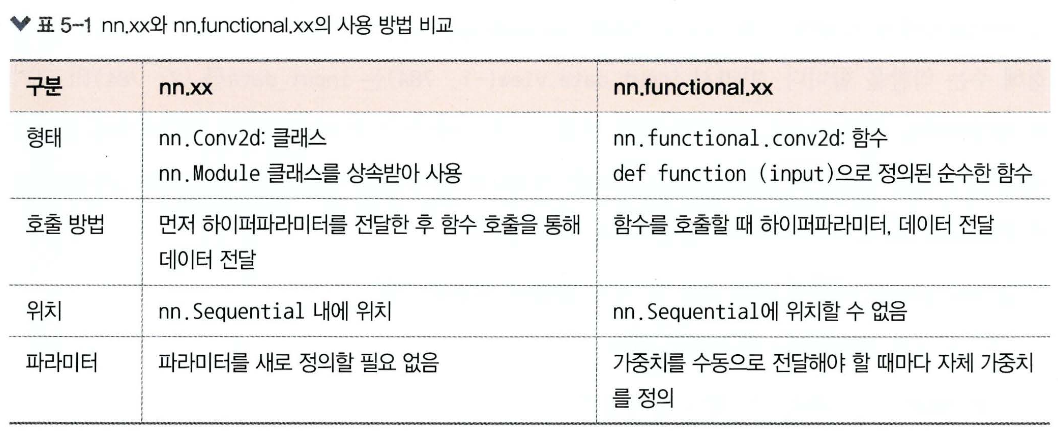

In [10]:
# 심층 신경망에서 필요한 파라미터 정의
learning_rate = 0.001
model = FashionDNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionDNN(
  (fc1): Linear(in_features=784, out_features=256, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=256, out_features=128, bias=True)
  (fc3): Linear(in_features=128, out_features=10, bias=True)
)


In [12]:
# 심층 신경망을 이용한 모델 학습
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 50):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 50, Loss: 0.7335882782936096, Accuracy: 69.1500015258789%
Iteration: 100, Loss: 0.5991117358207703, Accuracy: 76.69000244140625%
Iteration: 150, Loss: 0.6262179613113403, Accuracy: 77.66999816894531%
Iteration: 200, Loss: 0.6331149935722351, Accuracy: 80.5199966430664%
Iteration: 250, Loss: 0.49589991569519043, Accuracy: 80.72000122070312%
Iteration: 300, Loss: 0.507139265537262, Accuracy: 77.33000183105469%
Iteration: 350, Loss: 0.5392781496047974, Accuracy: 81.95999908447266%
Iteration: 400, Loss: 0.5641229152679443, Accuracy: 82.4000015258789%
Iteration: 450, Loss: 0.5817267298698425, Accuracy: 82.62999725341797%
Iteration: 500, Loss: 0.556410014629364, Accuracy: 83.77999877929688%
Iteration: 550, Loss: 0.4555901288986206, Accuracy: 83.37000274658203%
Iteration: 600, Loss: 0.39346885681152344, Accuracy: 84.11000061035156%
Iteration: 650, Loss: 0.3891706168651581, Accuracy: 84.01000213623047%
Iteration: 700, Loss: 0.4112546443939209, Accuracy: 84.0%
Iteration: 750, Loss: 0

In [13]:
# 합성곱 네트워크 생성
class FashionCNN(nn.Module):
  def __init__(self):
    super(FashionCNN, self).__init__()
    self.layer1 = nn.Sequential(
        nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1),
        nn.BatchNorm2d(32),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2)
    )
    self.layer2 = nn.Sequential(
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
        nn.BatchNorm2d(64),
        nn.ReLU(),
        nn.MaxPool2d(2)
    )
    self.fc1 = nn.Linear(in_features=64*6*6, out_features=600)
    self.drop = nn.Dropout(0.25)
    self.fc2 = nn.Linear(in_features=600, out_features = 120)
    self.fc3 = nn.Linear(in_features=120, out_features=10)

  def forward(self, x):
    out = self.layer1(x)
    out = self.layer2(out)
    out = out.view(out.size(0), -1)
    out = self.fc1(out)
    out = self.drop(out)
    out = self.fc2(out)
    out = self.fc3(out)
    return out

In [14]:
# 합성곱 네트워크를 위한 파라미터 정의
learning_rate = 0.001
model = FashionCNN()
model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(model)

FashionCNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (layer2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc1): Linear(in_features=2304, out_features=600, bias=True)
  (drop): Dropout(p=0.25, inplace=False)
  (fc2): Linear(in_features=600, out_features=120, bias=True)
  (fc3): Linear(in_features=120, out_features=10, bias=True)
)


In [15]:
# 모델 학습 및 성능 평가
num_epochs = 5
count = 0
loss_list = []
iteration_list = []
accuracy_list = []

predictions_list = []
labels_list = []

for epoch in range(num_epochs):
  for images, labels in train_loader:
    images, labels = images.to(device), labels.to(device)

    train = Variable(images.view(100, 1, 28, 28))
    labels = Variable(labels)

    outputs = model(train)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    count += 1

    if not (count % 50):
      total = 0
      correct = 0
      for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        labels_list.append(labels)
        test = Variable(images.view(100,1,28,28))
        outputs = model(test)
        predictions = torch.max(outputs, 1)[1].to(device)
        predictions_list.append(predictions)
        correct += (predictions == labels).sum()
        total += len(labels)

      accuracy = correct * 100 / total
      loss_list.append(loss.data)
      iteration_list.append(count)
      accuracy_list.append(accuracy)

    if not (count % 50):
      print('Iteration: {}, Loss: {}, Accuracy: {}%'.format(count, loss.data, accuracy))

Iteration: 50, Loss: 0.5046995282173157, Accuracy: 79.9800033569336%
Iteration: 100, Loss: 0.41884666681289673, Accuracy: 80.56999969482422%
Iteration: 150, Loss: 0.45853888988494873, Accuracy: 83.5199966430664%
Iteration: 200, Loss: 0.40655213594436646, Accuracy: 86.0199966430664%
Iteration: 250, Loss: 0.39678001403808594, Accuracy: 82.76000213623047%
Iteration: 300, Loss: 0.3794983923435211, Accuracy: 86.77999877929688%
Iteration: 350, Loss: 0.3664911985397339, Accuracy: 86.37999725341797%
Iteration: 400, Loss: 0.42312419414520264, Accuracy: 83.79000091552734%
Iteration: 450, Loss: 0.5957707166671753, Accuracy: 85.9800033569336%
Iteration: 500, Loss: 0.4632868468761444, Accuracy: 88.44999694824219%
Iteration: 550, Loss: 0.3556963801383972, Accuracy: 88.5999984741211%
Iteration: 600, Loss: 0.25119683146476746, Accuracy: 88.48999786376953%
Iteration: 650, Loss: 0.3369678854942322, Accuracy: 88.55999755859375%
Iteration: 700, Loss: 0.3362841010093689, Accuracy: 88.22000122070312%
Iterat

- nn.Sequential: 계층을 차례로 쌓을 수 있도록 Wx+b와 같은 수식과 활성화 함수를 연결

- nn.Conv2d()

[주요 파라미터]
- in_channels: 입력 채널의 수
- out_channels: 출력 채널의 수
- kernel_size: 커널의 크기
- padding: 패딩 크기
- 출력 크기 구하는 공식: (W - F + 2P) / S + 1
- BatchNorm2d: 학습 과정에서 각 배치 단위별로 데이터가 다양한 분포를 가지더라도 평균과 분산을 이용하여 정규화

- MaxPool2d: 이미지 크기를 축소시키는 용도로 사용

[주요 파라미터]
- kernel_size: m x n 행렬로 구성된 가중치
- stride: 입력 데이터에 커널을 적용할 때 이동할 간격
- 출력 크기 구하는 공식: IF / F